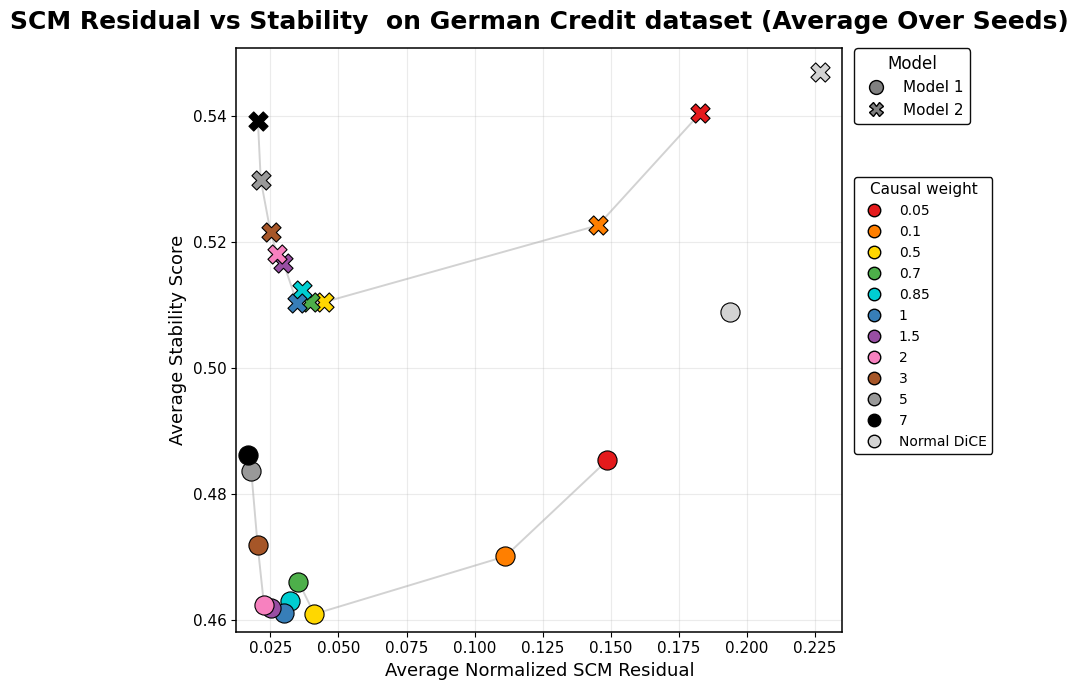

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# LOADING THE RESULT FILES AND VISUALIZING FROM THAT
RESULTS_DIR = r"C:\Users\irene\OneDrive\Υπολογιστής\TuE\BEP\BEP_CODE\NEW_PROJECTS_TRYING\even_newer_results"

cf_results = pd.read_csv(os.path.join(RESULTS_DIR, "final_cf_results.csv"))
residual_summaries = pd.read_csv(os.path.join(RESULTS_DIR, "final_residual_summaries.csv"))

# CODE TO VISUALIZE THE LINE PLOTS

# PREPARE DATA


def clean_model_name(x):
    x = str(x)
    if "Model 1" in x:
        return "Model 1"
    elif "Model 2" in x:
        return "Model 2"
    return x


cf_results["model_short"] = cf_results["model_name"].apply(clean_model_name)
residual_summaries["model_short"] = residual_summaries["model_name"].apply(clean_model_name)

cf_results["method"] = cf_results["method"].astype(str).str.lower()
residual_summaries["method"] = residual_summaries["method"].astype(str).str.lower()

# Make causal weights numeric
cf_results["causal_weight"] = pd.to_numeric(cf_results["causal_weight"], errors="coerce")
residual_summaries["causal_weight"] = pd.to_numeric(residual_summaries["causal_weight"], errors="coerce")


# Average stability over seeds
cf_avg = (
    cf_results
    .groupby(["method", "causal_weight", "model_short"], dropna=False)["stability_score"]
    .mean()
    .reset_index()
)

# Average SCM residual over seeds
res_avg = (
    residual_summaries
    .groupby(["method", "causal_weight", "model_short"], dropna=False)["avg_total_normalized_scm_residual"]
    .mean()
    .reset_index()
)

plot_df = cf_avg.merge(
    res_avg,
    on=["method", "causal_weight", "model_short"],
    how="inner"
)

normal_df = plot_df[plot_df["method"] == "normal"].copy()
causal_df = plot_df[plot_df["method"] == "causal"].copy()

causal_df["causal_weight"] = causal_df["causal_weight"].astype(float)
causal_df = causal_df.sort_values(["model_short", "causal_weight"])


# OFFSETS SO THAT LINES DONT EXCATLY OVERLAP


x_offset = {
    "Model 1": -0.0018,
    "Model 2": 0.0018
}

y_offset = {
    "Model 1": -0.0002,
    "Model 2": 0.0002
}

causal_df["x_plot"] = causal_df.apply(
    lambda r: r["avg_total_normalized_scm_residual"] + x_offset.get(r["model_short"], 0),
    axis=1
)

causal_df["y_plot"] = causal_df.apply(
    lambda r: r["stability_score"] + y_offset.get(r["model_short"], 0),
    axis=1
)

normal_df["x_plot"] = normal_df.apply(
    lambda r: r["avg_total_normalized_scm_residual"] + x_offset.get(r["model_short"], 0),
    axis=1
)

normal_df["y_plot"] = normal_df.apply(
    lambda r: r["stability_score"] + y_offset.get(r["model_short"], 0),
    axis=1
)


# PLOT STYLE


plt.style.use("default")

fig, ax = plt.subplots(figsize=(11, 7))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

marker_map = {
    "Model 1": "o",
    "Model 2": "X"
}

# weight_colors = {
#     0.05: "#4C78A8",
#     0.10: "#72B7B2",
#     0.50: "#54A24B",
#     0.70: "#EECA3B",
#     0.85: "#F58518",
#     1.00: "#E45756",
#     1.50: "#B279A2",
#     2.00: "#9D755D",
#     5.00: "#BAB0AC",
#
# }
weight_colors = {
    0.05: "#E41A1C",  # red
    0.10: "#FF7F00",  # orange
    0.50: "#FFD700",  # yellow/gold
    0.70: "#4DAF4A",  # green
    0.85: "#00CED1",  # turquoise
    1.00: "#377EB8",  # blue
    1.50: "#984EA3",  # purple
    2.00: "#F781BF",  # pink
    3.00: "#A65628",  # brown
    5.00: "#999999",  # grey
    7.00: "#000000"   # black
}

normal_color = "#2C2C2C"


# CONNECTING LINES

for model in ["Model 1", "Model 2"]:
    df_m = causal_df[causal_df["model_short"] == model].sort_values("causal_weight")

    ax.plot(
        df_m["x_plot"],
        df_m["y_plot"],
        color="gray",
        alpha=0.35,
        linewidth=1.4,
        zorder=1
    )


# CAUSAL POINTS

for _, row in causal_df.iterrows():
    ax.scatter(
        row["x_plot"],
        row["y_plot"],
        s=190,
        marker=marker_map.get(row["model_short"], "o"),
        color=weight_colors.get(row["causal_weight"], "#333333"),
        edgecolors="black",
        linewidths=0.8,
        zorder=3
    )


# NORMAL DICE POINTS

for _, row in normal_df.iterrows():
    ax.scatter(
        row["x_plot"],
        row["y_plot"],
        s=190,
        marker=marker_map.get(row["model_short"], "o"),
        color="lightgray",
        edgecolors="black",
        linewidths=0.8,
        zorder=4
    )



# AXIS LABELS AND TITLE

ax.set_title(
    "SCM Residual vs Stability  on German Credit dataset (Average Over Seeds)",
    fontsize=18,
    weight="bold",
    pad=14
)

ax.set_xlabel("Average Normalized SCM Residual", fontsize=13)
ax.set_ylabel("Average Stability Score", fontsize=13)

ax.grid(True, alpha=0.25, linewidth=0.8)

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.1)

ax.tick_params(axis="both", labelsize=11, colors="black")


ax.set_xlim(
    plot_df["avg_total_normalized_scm_residual"].min() - 0.006,
    plot_df["avg_total_normalized_scm_residual"].max() + 0.010
)

ax.set_ylim(
    plot_df["stability_score"].min() - 0.003,
    plot_df["stability_score"].max() + 0.004
)

# LEGEND 1: MODEL SHAPES


model_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        label="Model 1",
        markerfacecolor="gray",
        markeredgecolor="black",
        markersize=10,
        linewidth=0
    ),
    Line2D(
        [0], [0],
        marker="X",
        color="none",
        label="Model 2",
        markerfacecolor="gray",
        markeredgecolor="black",
        markersize=10,
        linewidth=0
    )
]

legend1 = ax.legend(
    handles=model_handles,
    title="Model",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    borderaxespad=0,
    frameon=True,
    fontsize=11,
    title_fontsize=12
)

legend1.get_frame().set_facecolor("white")
legend1.get_frame().set_edgecolor("black")
legend1.get_frame().set_alpha(0.95)

ax.add_artist(legend1)


# LEGEND 2: CAUSAL WEIGHTS


weight_handles = []

for w in sorted(causal_df["causal_weight"].dropna().unique()):
    weight_handles.append(
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            label=str(w).rstrip("0").rstrip("."),
            markerfacecolor=weight_colors.get(w, "#333333"),
            markeredgecolor="black",
            markersize=9,
            linewidth=0
        )
    )

weight_handles.append(
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        label="Normal DiCE",
        markerfacecolor="lightgray",
        markeredgecolor="black",
        markersize=9,
        linewidth=0
    )
)

legend2 = ax.legend(
    handles=weight_handles,
    title="Causal weight",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.78),
    borderaxespad=0,
    frameon=True,
    fontsize=10,
    title_fontsize=11
)

legend2.get_frame().set_facecolor("white")
legend2.get_frame().set_edgecolor("black")
legend2.get_frame().set_alpha(0.95)


# Leave space on the right for both legends
plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

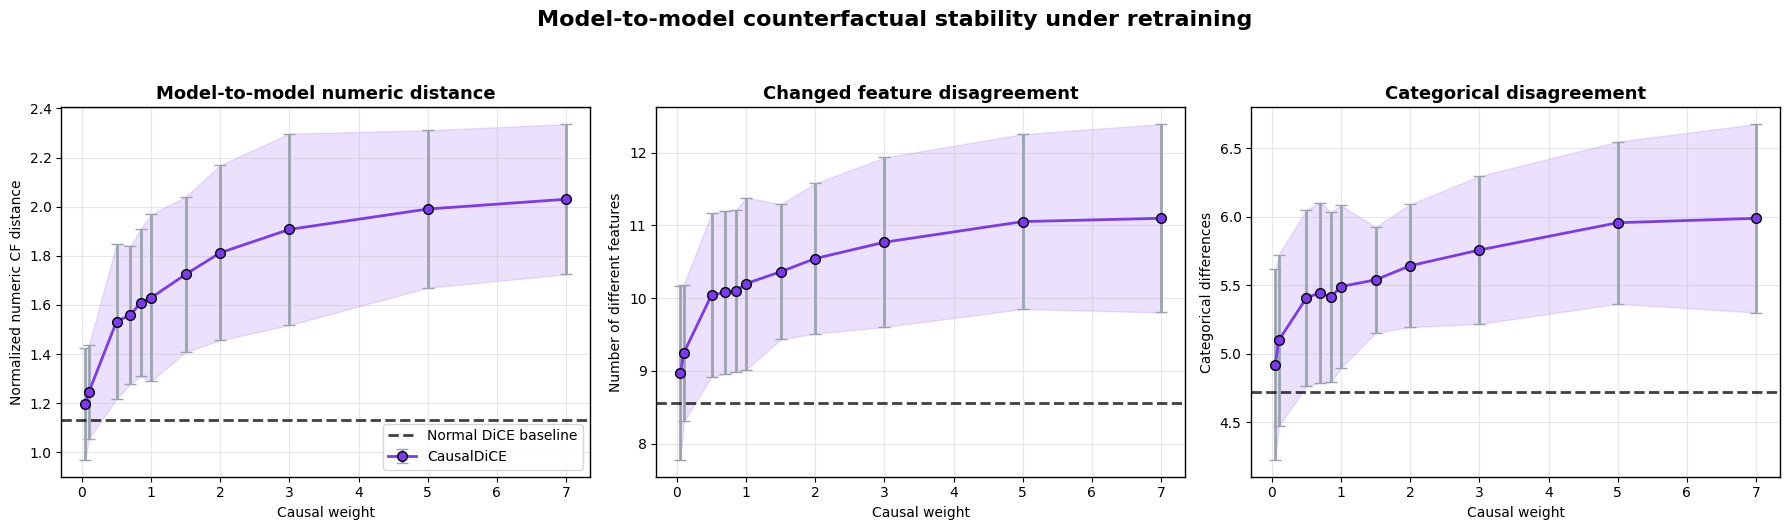

In [2]:

# CODE TO VISUALIZE THE MODEL TO MODEL ROBUSTNESS METRICS RESULTS
comparison = pd.read_csv(os.path.join(RESULTS_DIR, "final_comparison_summaries.csv"))

# Clean method names
comparison["method"] = comparison["method"].astype(str).str.lower().str.strip()

comparison["method_label"] = comparison["method"].replace({
    "normal": "Normal DiCE",
    "causal": "CausalDiCE"
})

# Make causal_weight numeric
comparison["causal_weight"] = pd.to_numeric(comparison["causal_weight"], errors="coerce")

metric_cols = [
    "avg_normalized_numeric_magnitude_between_models",
    "avg_n_features_different_between_models",
    "avg_categorical_differences_between_models"
]

# Make sure metrics are numeric
for col in metric_cols:
    comparison[col] = pd.to_numeric(comparison[col], errors="coerce")


# SUMMARY OVER SEEDS

summary = (
    comparison
    .groupby(["method", "causal_weight"], dropna=False)[metric_cols]
    .agg(["mean", "std"])
    .reset_index()
)

summary.columns = [
    "_".join(col).strip("_") if isinstance(col, tuple) else col
    for col in summary.columns
]

normal_df = summary[summary["method"] == "normal"].copy()
causal = summary[summary["method"] == "causal"].copy()

causal = causal.sort_values("causal_weight")

normal = normal_df.iloc[0]



plt.style.use("default")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

plots = [
    (
        "avg_normalized_numeric_magnitude_between_models",
        "Normalized numeric CF distance",
        "Model-to-model numeric distance"
    ),
    (
        "avg_n_features_different_between_models",
        "Number of different features",
        "Changed feature disagreement"
    ),
    (
        "avg_categorical_differences_between_models",
        "Categorical differences",
        "Categorical disagreement"
    )
]

for ax, (metric, ylabel, title) in zip(axes, plots):

    mean_col = metric + "_mean"
    std_col = metric + "_std"

    x = causal["causal_weight"].astype(float)
    y = causal[mean_col].astype(float)
    yerr = causal[std_col].fillna(0).astype(float)

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        marker="o",
        markersize=7,
        linewidth=2,
        capsize=4,
        color="#7C3AED",
        ecolor="#9CA3AF",
        markerfacecolor="#7C3AED",
        markeredgecolor="black",
        label="CausalDiCE"
    )

    ax.axhline(
        normal[mean_col],
        linestyle="--",
        linewidth=2,
        color="black",
        alpha=0.75,
        label="Normal DiCE baseline"
    )

    ax.fill_between(
        x,
        y - yerr,
        y + yerr,
        alpha=0.15,
        color="#7C3AED"
    )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Causal weight")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.0)

    ax.tick_params(axis="both", labelsize=10)


axes[0].legend(frameon=True)

fig.suptitle(
    "Model-to-model counterfactual stability under retraining",
    fontsize=16,
    fontweight="bold",
    y=1.05
)

plt.tight_layout()
plt.show()